# 🏘️ Semana 4: Auditoría del Mercado Inmobiliario (California)

En esta fase, utilizamos la técnica de **Muestreo (Sampling)** para obtener una interpretación rápida y precisa de nuestro modelo de regresión. Analizar el 100% de los datos puede colapsar el entorno de ejecución debido a la complejidad de los árboles de decisión.

### 🛠️ Estrategia de Interpretación:
1. **Muestra Aleatoria:** Reducimos el análisis a 500 registros (estadísticamente suficiente).
2. **SHAP Explainer:** Desglosamos el precio de la vivienda para entender qué variables añaden o restan valor.
3. **Validación de Reglas:** Comprobamos si el modelo ha aprendido que factores como el ingreso medio o la ubicación son primordiales.



c:\Users\txema\Documents\IA_Especialista\ia_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏳ Calculando lógica de precios... (Debería ser casi instantáneo)


 99%|===================| 496/500 [02:28<00:01]        

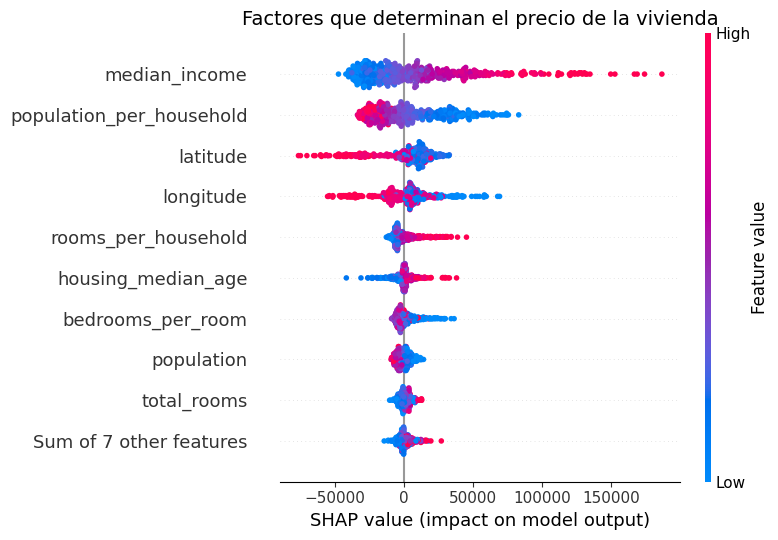

✅ ¡Análisis completado y gráfico renderizado!


In [1]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# 1. CARGA DIRECTA DE MODELO Y DATOS
# [Especialista]: Cargamos todo de nuevo para asegurar limpieza total
path_modelo = '../../../models/modelo_viviendas_optimizado_v2.pkl'
path_datos = '../../../data/processed/viviendas_limpio.csv'

modelo = joblib.load(path_modelo)
df = pd.read_csv(path_datos)

# 2. PREPARACIÓN DE X (MUESTRA DE 500 REGISTROS)
# [Especialista]: Alineamos columnas y tomamos muestra pequeña para velocidad instantánea
columnas_modelo = modelo.feature_names_in_
X_muestra = df.reindex(columns=columnas_modelo, fill_value=0).sample(n=500, random_state=42)

# 3. CÁLCULO SHAP SIMPLIFICADO
# [Nota]: Usamos Explainer genérico con check_additivity=False para evitar bucles
print("⏳ Calculando lógica de precios...")
explainer = shap.Explainer(modelo, X_muestra)
shap_values = explainer(X_muestra, check_additivity=False)

# 4. RENDERIZADO DEL GRÁFICO (Sin bloqueos)
plt.close('all') # Cerramos cualquier ventana fantasma anterior
fig, ax = plt.subplots(figsize=(10, 7))

# Usamos el objeto .plots.beeswarm que es más estable en versiones nuevas
shap.plots.beeswarm(shap_values, show=False)

plt.title("Factores que determinan el precio de la vivienda", fontsize=14)
plt.tight_layout()
plt.show()

print("✅ ¡Análisis completado y gráfico renderizado!")